# ISIC7 loader test (EfficientNet-B4) + CAM sanity check

Goal:
1) Load the 7-class EfficientNet-B4 checkpoint (HuggingFace `last_effnetb4.pth`)
2) Forward pass on 1 ISIC2018 image (logits shape must be (1,7))
3) Generate:
   - Grad-CAM(A)  (top-1 class)
   - Diff-CAM(A−B) (top-1 vs top-2)
4) Save overlays + metadata

In [1]:
import numpy as np
import torch

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("mps:", torch.backends.mps.is_available())

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)

numpy: 1.26.4
torch: 2.2.2
mps: True
Device: mps


In [3]:
from pathlib import Path
import pandas as pd
from PIL import Image
import cv2

import torchvision.transforms as T

REPO_ROOT = Path("..")  # notebook is in notebooks/
IMG_DIR  = REPO_ROOT / "data" / "isic2018" / "images_train"
CSV_PATH = REPO_ROOT / "data" / "isic2018" / "train_gt.csv"

CKPT_PATH = REPO_ROOT / "external" / "weights" / "isic7_last_effnetb4.pth"

OUT_DIR = REPO_ROOT / "outputs" / "isic7_debug_cam"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("IMG_DIR exists:", IMG_DIR.exists())
print("CSV_PATH exists:", CSV_PATH.exists())
print("CKPT_PATH exists:", CKPT_PATH.exists())
print("OUT_DIR:", OUT_DIR)

IMG_DIR exists: True
CSV_PATH exists: True
CKPT_PATH exists: True
OUT_DIR: ../outputs/isic7_debug_cam


CSV columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
Selected image: ISIC_0024306
Image path: ../data/isic2018/images_train/ISIC_0024306.jpg
Exists: True


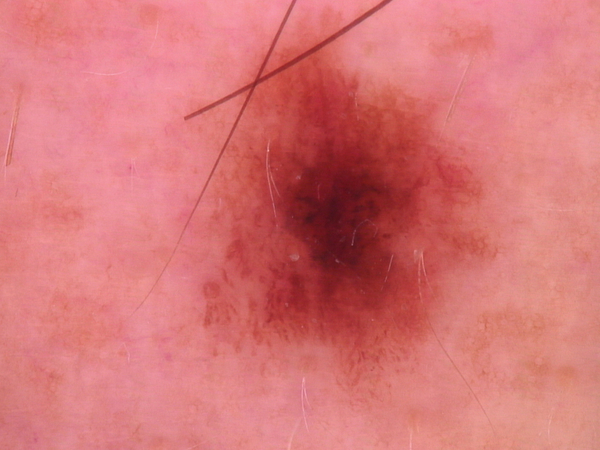

In [4]:
df = pd.read_csv(CSV_PATH)
print("CSV columns:", df.columns.tolist())
row = df.iloc[0]

image_id = row["image"]
img_path = IMG_DIR / f"{image_id}.jpg"
print("Selected image:", image_id)
print("Image path:", img_path)
print("Exists:", img_path.exists())

img = Image.open(img_path).convert("RGB")
img

In [5]:
IMAGE_SIZE = 380

preprocess = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

x = preprocess(img).unsqueeze(0)  # (1,3,380,380)
print("Input tensor shape:", x.shape, x.dtype)

rgb = np.array(img).astype(np.float32) / 255.0
rgb_380 = cv2.resize(rgb, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)

input_tensor = x.to(device)

Input tensor shape: torch.Size([1, 3, 380, 380]) torch.float32


In [6]:
import torch
from efficientnet_pytorch import EfficientNet

# 7-class mapping from the HF README
class_to_idx = {"AK":0, "BCC":1, "BKL":2, "DF":3, "MEL":4, "NV":5, "VASC":6}
idx_to_class = {v:k for k,v in class_to_idx.items()}

model = EfficientNet.from_name("efficientnet-b4")
model._fc = torch.nn.Linear(model._fc.in_features, 7)

state = torch.load(CKPT_PATH, map_location="cpu")
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]

# remove a possible "module." prefix
if isinstance(state, dict):
    cleaned = {}
    for k, v in state.items():
        if k.startswith("module."):
            k = k[len("module."):]
        cleaned[k] = v
    state = cleaned

missing, unexpected = model.load_state_dict(state, strict=False)
print("Missing:", len(missing))
print("Unexpected:", len(unexpected))
if missing: print("Missing sample:", missing[:10])
if unexpected: print("Unexpected sample:", unexpected[:10])

model.eval()
model = model.to(device)

print(model.__class__.__name__)

Missing: 0
Unexpected: 0
EfficientNet


In [7]:
import torch.nn.functional as F

with torch.no_grad():
    logits = model(input_tensor)  # (1,7)

print("Logits shape:", logits.shape)
probs = F.softmax(logits, dim=1)[0]  # (7,)

top2 = torch.topk(probs, k=2)
A = int(top2.indices[0].item())
B = int(top2.indices[1].item())

print("Top-3 probs:", torch.topk(probs, k=3).values.detach().cpu().numpy())
print("A (top1):", A, idx_to_class[A], "| B (top2):", B, idx_to_class[B])

Logits shape: torch.Size([1, 7])
Top-3 probs: [1.0000000e+00 1.1585477e-11 7.5463811e-12]
A (top1): 5 NV | B (top2): 4 MEL


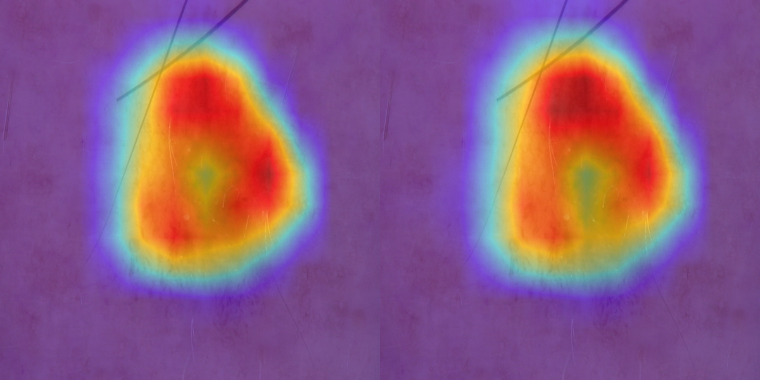

In [8]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# CAM target layer for efficientnet_pytorch
target_layer = model._conv_head
cam = GradCAM(model=model, target_layers=[target_layer])

class LogitDiffTarget:
    """Target: logit[A] - logit[B]."""
    def __init__(self, a: int, b: int):
        self.a, self.b = int(a), int(b)
    def __call__(self, o: torch.Tensor):
        # grad-cam passes o as (C,) for single image
        return o[self.a] - o[self.b]

# Grad-CAM for A
cam_A = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(A)])[0]
vis_A = show_cam_on_image(rgb_380, cam_A, use_rgb=True)

# Diff-CAM (A - B)
cam_diff = cam(input_tensor=input_tensor, targets=[LogitDiffTarget(A, B)])[0]
vis_diff = show_cam_on_image(rgb_380, cam_diff, use_rgb=True)

Image.fromarray(np.hstack([vis_A, vis_diff]))

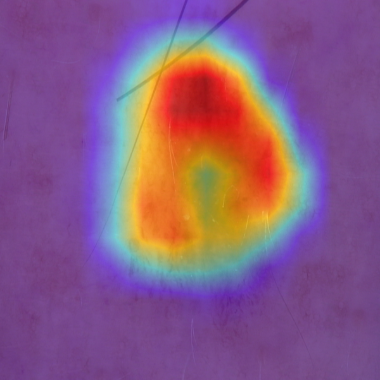

In [9]:
from pytorch_grad_cam import LayerCAM

layercam = LayerCAM(model=model, target_layers=[model._conv_head])
cam_diff_l = layercam(input_tensor=input_tensor, targets=[LogitDiffTarget(A, B)])[0]
vis_diff_l = show_cam_on_image(rgb_380, cam_diff_l, use_rgb=True)

Image.fromarray(vis_diff_l)

In [10]:
import json
from PIL import Image

panel_path = OUT_DIR / f"{image_id}_A_and_DIFF_gradcam.png"
layercam_path = OUT_DIR / f"{image_id}_DIFF_layercam.png"

Image.fromarray(np.hstack([vis_A, vis_diff])).save(panel_path)
Image.fromarray(vis_diff_l).save(layercam_path)

meta = {
    "image_id": image_id,
    "img_path": str(img_path),
    "checkpoint": CKPT_PATH.name,
    "arch": "efficientnet-b4",
    "image_size": IMAGE_SIZE,
    "device": device,
    "A_top1": A,
    "B_top2": B,
    "A_name": idx_to_class[A],
    "B_name": idx_to_class[B],
    "probs_top3": torch.topk(probs, 3).values.detach().cpu().tolist(),
    "panel_path": str(panel_path),
    "layercam_diff_path": str(layercam_path),
}

meta_path = OUT_DIR / f"{image_id}_meta.json"
meta_path.write_text(json.dumps(meta, indent=2))

print("Saved:", panel_path.name)
print("Saved:", layercam_path.name)
print("Saved:", meta_path.name)

Saved: ISIC_0024306_A_and_DIFF_gradcam.png
Saved: ISIC_0024306_DIFF_layercam.png
Saved: ISIC_0024306_meta.json
